# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
<VSCode.Cell language="python">
file_path = '../Customer-Segmentation_raw.csv'
df = pd.read_csv(file_path)

display(df.head())
</VSCode.Cell>

,Age,AnnualIncome,AverageTransactionValue,DiscountSensitivity,ShoppingFrequency
0,36,71412,1697,Medium,Occasional
1,49,79363,1062,Medium,Frequent
2,44,53373,1848,Low,Frequent
3,40,47755,2723,Medium,Rare
4,37,38296,966,Medium,Rare


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      2500 non-null   int64
 1   AnnualIncome             2500 non-null   int64
 2   AverageTransactionValue  2500 non-null   int64
 3   DiscountSensitivity      2500 non-null   str  
 4   ShoppingFrequency        2500 non-null   str  
dtypes: int64(3), str(2)
memory usage: 97.8 KB


In [5]:
df.describe()

,Age,AnnualIncome,AverageTransactionValue
count,2500.000000,2500.0000,2500.000000
mean,37.124400,59566.6380,1287.364800
std,9.283846,20135.1691,889.624849
min,15.000000,5000.0000,50.000000
25%,30.000000,45810.2500,572.500000
50%,37.000000,59848.0000,1226.500000
75%,44.000000,72952.2500,1880.000000
max,63.000000,138524.0000,5000.000000


In [6]:
discount_sensitivity_counts = df['DiscountSensitivity'].value_counts()
display(discount_sensitivity_counts)

DiscountSensitivity
High      1209
Medium    1077
Low        214
Name: count, dtype: int64

In [7]:
shopping_frequency_counts = df['ShoppingFrequency'].value_counts()
display(shopping_frequency_counts)

ShoppingFrequency
Frequent      1227
Occasional    1010
Rare           263
Name: count, dtype: int64

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

### Menghapus atau Menangani Data Kosong (Missing Values)

Langkah pertama dalam penanganan data kosong adalah mengidentifikasi dan menghitung berapa banyak nilai yang hilang di setiap kolom. Ini akan memberikan gambaran tentang seberapa parah masalah data kosong tersebut.

In [8]:
df.isnull().sum()

Age                        0
AnnualIncome               0
AverageTransactionValue    0
DiscountSensitivity        0
ShoppingFrequency          0
dtype: int64

### Menghapus Data Duplikat

Setelah memastikan tidak ada data yang kosong, langkah selanjutnya adalah memeriksa dan menangani data duplikat. Data duplikat dapat memengaruhi analisis dan model, jadi penting untuk mengidentifikasinya.

In [9]:
df.duplicated().sum()

np.int64(0)

### Normalisasi atau Standarisasi Fitur

Setelah menangani nilai yang hilang dan duplikasi, langkah selanjutnya adalah normalisasi atau standardisasi fitur. Proses ini memastikan bahwa semua fitur memiliki skala yang serupa, yang penting untuk kinerja banyak algoritma machine learning.

In [10]:
# Identifikasi kolom numerik
numerical_cols = ['Age', 'AnnualIncome', 'AverageTransactionValue']

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Terapkan StandardScaler pada kolom numerik
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Tampilkan 5 baris pertama DataFrame setelah normalisasi untuk verifikasi
display(df.head())

,Age,AnnualIncome,AverageTransactionValue,DiscountSensitivity,ShoppingFrequency
0,-0.121138,0.588410,0.460550,Medium,Occasional
1,1.279424,0.983370,-0.253376,Medium,Frequent
2,0.740746,-0.307665,0.630319,Low,Frequent
3,0.309804,-0.586735,1.614076,Medium,Rare
4,-0.013402,-1.056604,-0.361309,Medium,Rare


### Deteksi dan Penanganan Outlier

Outlier adalah titik data yang secara signifikan berbeda dari titik data lainnya dan dapat memengaruhi hasil analisis atau model machine learning. Penting untuk mendeteksi dan memutuskan cara menanganinya (misalnya, menghapus, mengubah, atau membiarkannya) berdasarkan konteks data.

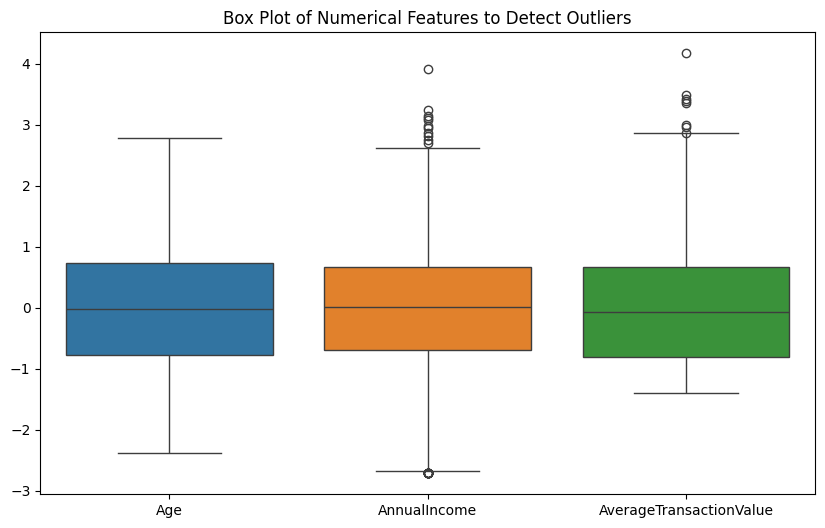

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numerical_cols])
plt.title('Box Plot of Numerical Features to Detect Outliers')
plt.show()

In [12]:
# Terapkan capping untuk outlier pada kolom 'AnnualIncome' dan 'AverageTransactionValue'
for col in ['AnnualIncome', 'AverageTransactionValue']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

# Tampilkan 5 baris pertama DataFrame setelah penanganan outlier untuk verifikasi
display(df.head())

,Age,AnnualIncome,AverageTransactionValue,DiscountSensitivity,ShoppingFrequency
0,-0.121138,0.588410,0.460550,Medium,Occasional
1,1.279424,0.983370,-0.253376,Medium,Frequent
2,0.740746,-0.307665,0.630319,Low,Frequent
3,0.309804,-0.586735,1.614076,Medium,Rare
4,-0.013402,-1.056604,-0.361309,Medium,Rare


### Encoding Data Kategorikal

Berdasarkan analisis kita, kolom `DiscountSensitivity` dan `ShoppingFrequency` adalah data ordinal karena memiliki urutan yang bermakna. Kita akan menggunakan `OrdinalEncoder` dari `sklearn.preprocessing` untuk mengubahnya menjadi representasi numerik. Penting untuk menentukan urutan kategori secara eksplisit agar encoder menetapkan nilai numerik sesuai dengan urutan logis.

Untuk `DiscountSensitivity`, urutan akan dari 'Low' ke 'High': `['Low', 'Medium', 'High']`.
Untuk `ShoppingFrequency`, urutan akan dari 'Rare' ke 'Frequent': `['Rare', 'Occasional', 'Frequent']`.

In [13]:
# Define the order for each ordinal categorical column
discount_sensitivity_order = ['Low', 'Medium', 'High']
shopping_frequency_order = ['Rare', 'Occasional', 'Frequent']

# Check if the columns still need encoding (i.e., if they are still 'object' dtype)
# This prevents re-encoding already encoded numerical columns
if df['DiscountSensitivity'].dtype == 'object' and df['ShoppingFrequency'].dtype == 'object':
    # Initialize the OrdinalEncoder with the specified categories
    # We pass a list of lists, where each inner list is the order for one column
    encoder = OrdinalEncoder(categories=[discount_sensitivity_order, shopping_frequency_order])

    # Apply the encoder to the categorical columns
    df[['DiscountSensitivity', 'ShoppingFrequency']] = encoder.fit_transform(df[['DiscountSensitivity', 'ShoppingFrequency']])
    print("Categorical columns encoded successfully.")
else:
    print("Categorical columns are already numerical, skipping encoding.")

# Display the first few rows of the DataFrame to verify the encoding
display(df.head())

Categorical columns are already numerical, skipping encoding.


,Age,AnnualIncome,AverageTransactionValue,DiscountSensitivity,ShoppingFrequency
0,-0.121138,0.588410,0.460550,Medium,Occasional
1,1.279424,0.983370,-0.253376,Medium,Frequent
2,0.740746,-0.307665,0.630319,Low,Frequent
3,0.309804,-0.586735,1.614076,Medium,Rare
4,-0.013402,-1.056604,-0.361309,Medium,Rare


### Binning (Pengelompokan Data)

Binning, atau pengelompokan data, adalah proses mengelompokkan nilai-nilai numerik menjadi beberapa kategori atau "bin". Ini sering digunakan untuk mengubah fitur numerik kontinu menjadi fitur kategorikal ordinal, yang dapat membantu dalam beberapa model machine learning atau untuk mempermudah interpretasi data. Mari kita terapkan binning pada kolom 'Age' untuk mengelompokkan pelanggan ke dalam kategori usia.

In [15]:
# Tentukan batas-batas bin dan label untuk kolom 'Age'
age_bins = [df['Age'].min() - 1, -0.5, 0.5, df['Age'].max() + 1] # Using scaled age values
age_labels = ['Young', 'Adult', 'Senior']

# Lakukan binning pada kolom 'Age'
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)

# Tampilkan jumlah setiap kelompok usia baru
display(df['AgeGroup'].value_counts())

# Tampilkan beberapa baris pertama DataFrame untuk memverifikasi kolom baru
display(df.head())

AgeGroup
Young     844
Adult     834
Senior    822
Name: count, dtype: int64

,Age,AnnualIncome,AverageTransactionValue,DiscountSensitivity,ShoppingFrequency,AgeGroup
0,-0.121138,0.588410,0.460550,Medium,Occasional,Adult
1,1.279424,0.983370,-0.253376,Medium,Frequent,Senior
2,0.740746,-0.307665,0.630319,Low,Frequent,Senior
3,0.309804,-0.586735,1.614076,Medium,Rare,Adult
4,-0.013402,-1.056604,-0.361309,Medium,Rare,Adult


In [16]:
# Initialize a new OrdinalEncoder specifically for AgeGroup
# The order 'Young', 'Adult', 'Senior' is explicitly defined using 'age_labels'
age_group_encoder = OrdinalEncoder(categories=[age_labels])

# Apply the encoder to the 'AgeGroup' column
df['AgeGroup'] = age_group_encoder.fit_transform(df[['AgeGroup']])

# Display the first few rows to verify the encoding
display(df.head())

,Age,AnnualIncome,AverageTransactionValue,DiscountSensitivity,ShoppingFrequency,AgeGroup
0,-0.121138,0.588410,0.460550,Medium,Occasional,1.0
1,1.279424,0.983370,-0.253376,Medium,Frequent,2.0
2,0.740746,-0.307665,0.630319,Low,Frequent,2.0
3,0.309804,-0.586735,1.614076,Medium,Rare,1.0
4,-0.013402,-1.056604,-0.361309,Medium,Rare,1.0


In [ ]:
<VSCode.Cell language="python">
# Save preprocessing result to a new CSV file in the preprocessing folder
output_path = 'Customer-Segmentation_preprocessing.csv'
df.to_csv(output_path, index=False)
print(f"Saved preprocessing result to: {output_path}")
</VSCode.Cell>

Saved preprocessing result to: Customer-Segmentation_preprocessing.csv
